In [1]:
import pandas as pd

from astropy.coordinates import SkyCoord
import astropy.units as u


In [23]:
path = '/home/nicolas/nico/Data/Masivas/Data_OB_stars/resultados_V2/Discussion/'

In [125]:
IACOB = pd.read_csv(path+"IACOB.csv",delimiter=",")

In [126]:
ALS = pd.read_csv(path+"ALS",delimiter=",")

In [127]:
ALS = ALS.loc[ALS["SpType"].notna()]

In [139]:
goss = pd.read_csv(path+"goss.csv",delimiter="|")

In [129]:
Li = pd.read_csv(path+"Li2021.csv")

In [130]:
besos = pd.read_csv(path+"BESOS.csv")

In [9]:
IACOB["ref"] ="IACOB"
ALS["ref"] = "ALS"
goss["ref"] = "GOSSS"
Li["ref"] = "LI"
besos["ref"] = "BESOS"

In [10]:
IACOB = IACOB[["RA_deg", "Dec_deg", "sp_IACOB", "ref"]].rename(columns={"sp_IACOB": "sp"})


In [11]:
coord = SkyCoord(ra=goss["ra"].values, dec=goss["dec"].values, unit=(u.hourangle, u.deg))


In [12]:
goss["RA_deg"] = coord.ra.deg
goss["Dec_deg"] = coord.dec.deg

In [13]:
goss = goss[["RA_deg","Dec_deg","sp_GOSS","ref"]].rename(columns={"sp_GOSS": "sp"})

In [14]:
besos = besos[["_RA","_DE","SpType","ref"]].rename(columns={"SpType": "sp",
                                                  "_RA":"RA_deg",
                                                   "_DE":"Dec_deg"})

In [15]:
Li = Li[["RAJ2000","DEJ2000","SpT","ref"]].rename(columns={"SpT": "sp",
                                                  "RAJ2000":"RA_deg",
                                                   "DEJ2000":"Dec_deg"})

In [16]:
ALS = ALS[["RA","DEC","ref","SpType"]].rename(columns={"SpType": "sp","RA":"RA_deg",
                                                   "DEC":"Dec_deg"})

In [17]:
ALS = ALS.loc[(ALS["sp"].notna())]

In [18]:
skiff = pd.read_csv(path+"Skiff_B2_or_earlier.csv")

In [19]:
coord = SkyCoord(ra=skiff["RAJ2000"].values, dec=skiff["DEJ2000"].values, unit=(u.hourangle, u.deg))
skiff["RA_deg"] = coord.ra.deg
skiff["Dec_deg"] = coord.dec.deg

In [20]:
# Redondear a 1 decimal
skiff["rounded"] = skiff["numeric_sp"].round(1)

# Obtener tipo espectral
skiff["main_type"] = skiff["rounded"].astype(int)  # 0 → O, 1 → B
skiff["subtype"] = ((skiff["rounded"] * 10) % 10).astype(int)

# Construir etiqueta
skiff["label"] = skiff.apply(
    lambda row: "O" if row["main_type"] == 0 and row["subtype"] == 0
    else f"{'O' if row['main_type'] == 0 else 'B'}{row['subtype']}",
    axis=1
)

In [ ]:
hay compilaciones muy especificas como IACOB, LI y GOSS
Hay compilaciones especificas como ALS
hay compilaciones mas generales como SKiff


In [227]:
IACOB = IACOB.loc[(IACOB["sp"].str[0:2]!="B3")&
           (IACOB["sp"].str[0:2]!="B4")& 
          (IACOB["sp"].str[0:2]!="B5")&
          (IACOB["sp"].str[0:2]!="B6")&
          (IACOB["sp"].str[0:2]!="B8")&
         (IACOB["sp"].str[0:2]!="B9")&
        (IACOB["sp"].str[0:2]!="OB")&
          (IACOB["sp"].str[0:2]!="OB")&
         (IACOB["sp"].str[0]!="A")
         ]

In [311]:
ALS["sp"] = ALS["sp"].str.split(",")
ALS = ALS.explode("sp").reset_index(drop=True)

In [312]:
ALS["sp"] = ALS["sp"].str.replace(" ", "", regex=False)

In [313]:
ALS = ALS.loc[(ALS["sp"].str[0:2]!="B3")&
           (ALS["sp"].str[0:2]!="B4")& 
          (ALS["sp"].str[0:2]!="B5")&
          (ALS["sp"].str[0:2]!="B6")&
        (ALS["sp"].str[0:2]!="B7")&
          (ALS["sp"].str[0:2]!="B8")&
         (ALS["sp"].str[0:2]!="B9")&
        (ALS["sp"].str[0:2]!="OB")&
        (ALS["sp"].str[0:2]!="Be")&
        (ALS["sp"].str[0:2]!="Bn")&
        (ALS["sp"].str[0:2]!="Bp")&
               (ALS["sp"].str[0:3]!="B(3")&
              (ALS["sp"].str[0:3]!="B/A")&
        (ALS["sp"].str[0]!="F")&
        (ALS["sp"].str[0]!="W")&
              (ALS["sp"].str[0]!="(")&
              (ALS["sp"].str[0]!="p")&
         (ALS["sp"].str[0]!="A")].drop_duplicates(subset="RA_deg")

In [321]:
ALS = ALS.loc[~(ALS["sp"].str.len()==1)&(ALS["sp"].str[0]=="B")]

In [324]:
IACOB = IACOB.loc[~(IACOB["sp"].str.len()==1)&(IACOB["sp"].str[0]=="B")]

In [325]:
pd.concat([skiff,ALS,goss,IACOB,Li]).to_csv(path+"Skiff_GOSSS_ALS_Li_IACOB.csv",index=False)

In [23]:
df_internal_match = pd.read_csv(path+"GOSSS_chen_ALS_Li_IACOB.csv")

In [143]:
df_internal_match.loc[((df_internal_match["ref"]=="LI")|
                      (df_internal_match["ref"]=="IACOB")|
                     (df_internal_match["ref"]=="GOSSS"))&(df_internal_match["GroupID"].notna())].drop_duplicates(subset="GroupID")

,RA_deg,Dec_deg,ref,sp,GroupID,GroupSize
15,259.757012,-38.819622,GOSSS,O9,8.0,2.0
17,281.709170,-3.730182,LI,O7 V,9.0,2.0
34,274.656225,-13.727608,GOSSS,O7,17.0,3.0
48,92.232587,15.705053,GOSSS,O7.5,24.0,2.0
50,93.092140,18.016080,LI,O9.7 V,25.0,2.0
...,...,...,...,...,...,...
3854,35.799030,57.472045,IACOB,OB,1781.0,2.0
3856,40.284119,61.135274,IACOB,O9.5IV,1782.0,2.0
3858,79.594818,41.935000,IACOB,O7V((f))z,1783.0,2.0
3860,82.696285,5.948367,IACOB,B7V,1784.0,2.0


In [141]:
df_internal_match.loc[((df_internal_match["ref"]=="LI")|
                      (df_internal_match["ref"]=="IACOB")|
                     (df_internal_match["ref"]=="GOSSS"))&(df_internal_match["GroupID"].isna())]

,RA_deg,Dec_deg,ref,sp,GroupID,GroupSize
16757,100.244400,9.895753,GOSSS,O7,NaN,NaN
16758,109.668242,-24.558700,GOSSS,O7,NaN,NaN
16759,155.670671,-59.508494,GOSSS,O7,NaN,NaN
16760,155.682392,-59.505061,GOSSS,O8,NaN,NaN
16761,164.634954,-61.182361,GOSSS,O5,NaN,NaN
...,...,...,...,...,...,...
17432,102.181210,-0.257652,LI,O6 Iafp,NaN,NaN
17433,103.183440,-0.187991,LI,O9.5 Vne,NaN,NaN
17434,102.596030,-0.540200,LI,O9.5 V,NaN,NaN
17435,101.550780,-2.914206,LI,O9 V,NaN,NaN


In [145]:
df_internal_match.loc[((df_internal_match["ref"]=="ALS")|
                      (df_internal_match["ref"]=="Chen+2019"))&(df_internal_match["GroupID"].notna())].drop_duplicates(subset="GroupID")

,RA_deg,Dec_deg,ref,sp,GroupID,GroupSize
0,112.508200,-18.541170,Chen+2019,chenCandidates,1.0,2.0
2,264.034320,-33.482050,Chen+2019,chenCandidates,2.0,2.0
4,264.119850,-33.525750,Chen+2019,chenCandidates,3.0,2.0
6,264.134310,-33.531130,Chen+2019,chenCandidates,4.0,2.0
8,264.188310,-33.531930,Chen+2019,chenCandidates,5.0,2.0
...,...,...,...,...,...,...
3688,305.859433,-14.256435,ALS,"B3II/III, B5IV",1700.0,2.0
3690,312.102367,3.649044,ALS,B7III,1701.0,2.0
3692,158.978754,-58.216414,ALS,B1V,1702.0,2.0
3694,158.930346,-58.225997,ALS,B1.5III,1703.0,2.0


In [156]:
subset = df_internal_match.drop_duplicates(subset="GroupID")

In [150]:
df_internal_match.loc[((df_internal_match["ref"]=="ALS")|
                      (df_internal_match["ref"]=="Chen+2019"))&(df_internal_match["GroupID"].isna())]

,RA_deg,Dec_deg,ref,sp,GroupID,GroupSize
3864,270.471125,-24.313026,ALS,B1Ib,NaN,NaN
3865,270.853721,-22.617058,ALS,B3NN,NaN,NaN
3866,270.963162,-27.303873,ALS,"B2IVp, B2III",NaN,NaN
3867,271.030596,-24.323947,ALS,B8,NaN,NaN
3868,271.062617,-24.391041,ALS,"B3n, B2Vne",NaN,NaN
...,...,...,...,...,...,...
16752,274.792917,-13.817757,ALS,B9III,NaN,NaN
16753,274.692221,-13.823184,ALS,B5III,NaN,NaN
16754,274.704867,-13.801182,ALS,B5III,NaN,NaN
16755,251.765104,-45.837340,ALS,B5Ia+,NaN,NaN


In [157]:
subset.loc[((subset["ref"]=="ALS")|
                      (subset["ref"]=="Chen+2019"))&(subset["GroupID"].notna())].drop_duplicates(subset="GroupID")

,RA_deg,Dec_deg,ref,sp,GroupID,GroupSize
0,112.508200,-18.541170,Chen+2019,chenCandidates,1.0,2.0
2,264.034320,-33.482050,Chen+2019,chenCandidates,2.0,2.0
4,264.119850,-33.525750,Chen+2019,chenCandidates,3.0,2.0
6,264.134310,-33.531130,Chen+2019,chenCandidates,4.0,2.0
8,264.188310,-33.531930,Chen+2019,chenCandidates,5.0,2.0
...,...,...,...,...,...,...
3688,305.859433,-14.256435,ALS,"B3II/III, B5IV",1700.0,2.0
3690,312.102367,3.649044,ALS,B7III,1701.0,2.0
3692,158.978754,-58.216414,ALS,B1V,1702.0,2.0
3694,158.930346,-58.225997,ALS,B1.5III,1703.0,2.0


In [150]:
df = pd.read_csv(path+"Data_compilation_Xmatch_2arcsec_Li2021_ALS_Simbad_GOSS_BESOS_IACOB.csv")

/tmp/ipykernel_43242/3676922434.py:1: DtypeWarning: Columns (16,17) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path+"Data_compilation_Xmatch_2arcsec_Li2021_ALS_Simbad_GOSS_BESOS_IACOB.csv")


In [151]:
df_lamost = pd.read_csv("/home/nicolas/nico/Data/Masivas/Data_OB_stars/spectra/LAMOST_low_resolution/Lamost_Contain_Rectangle_sp.csv")

In [152]:
df = df.merge(df_lamost[["index","sp"]],how="left",on="index")

In [153]:
df = df.rename(columns={"sp":"sp_Monsalves+2025"})

In [154]:
data = pd.read_csv("/home/nicolas/nico/Data/Masivas/Data_OB_stars/resultados_V2/Data.csv")


/tmp/ipykernel_43242/2341741171.py:1: DtypeWarning: Columns (49,50,51,52,72) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("/home/nicolas/nico/Data/Masivas/Data_OB_stars/resultados_V2/Data.csv")


In [158]:
df = df.drop(columns="skiff_type")

In [159]:
df = df.merge(data[["index","Gmag","BPmag",'RPmag',"skiff_type_list"]],how="left",on="index")

In [160]:
coded_alonso = pd.read_csv("/home/nicolas/nico/Data/Masivas/Data_OB_stars/OBAGDR3_2arcsecSkiff_grouped_sd_3_without_OB_without_non_consec_lum.csv")


/tmp/ipykernel_43242/3605798377.py:1: DtypeWarning: Columns (1,2,9) have mixed types. Specify dtype option on import or set low_memory=False.
  coded_alonso = pd.read_csv("/home/nicolas/nico/Data/Masivas/Data_OB_stars/OBAGDR3_2arcsecSkiff_grouped_sd_3_without_OB_without_non_consec_lum.csv")


In [161]:
import re

In [162]:
coded_alonso["source_id"] = coded_alonso["source_id"].apply(
    lambda x: list(map(int, re.findall(r"\d+", x))) if isinstance(x, str) else x
)

In [163]:
coded_alonso = coded_alonso.explode("source_id")

In [164]:
df = df.merge(coded_alonso[["source_id","skiff_type","Bibcode","is_OB"]],how="left",on="source_id")

In [165]:
df = df.drop_duplicates(subset="source_id")

In [166]:
df

,index,source_id,ra_1,dec_1,Bibcode_skiff,B2_cut_probability,B2_cut_split,Sp_monsalves2024,sp_Li2021,Cat,...,sep_simbad,sp_Monsalves+2025,Gmag,BPmag,RPmag,skiff_type_list,GroupSize_skiff,skiff_type,Bibcode,is_OB
0,281628,458762022584923136,33.994564,58.293614,"['1959LS....C01....0H', '1963JO.....46..243B',...",0.555833,train,NaN,NaN,M,...,0.021301,NaN,7.354769,7.822298,6.681507,"['A0Iab', 'A2Iab', 'B9Iab', 'A0Ia', 'A1Ib', 'A...",12.0,"['A0Iab', 'A2Iab', 'A0Iab', 'B9Iab', 'A0Ia', '...","['1959LS....C01....0H', '1963JO.....46..243B',...",0.0
11,53573,458457320427789824,35.281955,57.166788,['1949UppAn...3b....W'],0.951111,NaN,NaN,NaN,NaN,...,0.018208,NaN,9.411669,9.578321,9.090600,NaN,NaN,NaN,NaN,NaN
12,366012,4069663589522760448,271.012200,-22.565961,"['1937LicOB..18...89Z', '1943ApJ....97..300N',...",0.715833,train,NaN,NaN,M,...,0.023595,NaN,8.239204,8.209863,8.224721,"['B3', 'B5', 'B1/2III', 'B1V']",7.0,"['B3', 'B5', 'B3', 'B1/2III', 'B1V']","['1937LicOB..18...89Z', '1943ApJ....97..300N',...",0.0
17,1079351,4042411609752563200,269.984779,-33.890833,"['1977ApJS...35..111G', '1982MSS...C03....0H',...",0.953333,train,NaN,NaN,M,...,0.045741,NaN,8.258897,8.350165,8.038120,"['B1Ib', 'B2Ib/II', 'B']",6.0,"['B1Ib', 'B2Ib/II', 'B']","['1977ApJS...35..111G', '1982MSS...C03....0H',...",0.0
20,1047552,3397264469089651456,83.060677,17.056005,"['1959ApJ...130..159O', '1969AJ.....74..375C',...",0.132500,train,NaN,NaN,NaN,...,0.171943,NaN,6.464407,6.473603,6.390491,"['B8V', 'B7IV', 'B8']",9.0,"['B8V', 'em', 'B8V', 'em', 'B7IV', 'B8', 'B8',...","['1959ApJ...130..159O', '1970PASP...82.1357W',...",0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126265,1089111,4054578186917712512,263.275064,-33.057810,"['1982MSS...C03....0H', '1969MNRAS.144...31B',...",0.819167,train,NaN,NaN,M,...,0.079905,NaN,7.213738,7.285029,7.023167,"['B2II', 'B3II', 'B']",5.0,"['B2II', 'B5Vn', 'B3II', 'B']","['1982MSS...C03....0H', '1973Obs....93...75W',...",0.0
126269,871512,511264699246655488,26.599082,61.258254,"['1974AJ.....79..597M', '1961AbaOB..26...35K',...",0.815000,train,NaN,NaN,M,...,0.018811,NaN,8.284625,8.662474,7.704534,"['B5Ib', 'B5I', 'B6Iab', 'B2', 'B1', 'B0']",13.0,"['B5Ib', 'B5I', 'B6Iabe', 'B6Iab', 'B2', 'B5:'...","['1974AJ.....79..597M', '1961AbaOB..26...35K',...",0.0
126278,965933,5971216963502652288,253.134733,-38.436110,"['1982MSS...C03....0H', '1977ApJS...35..111G']",0.948333,train,NaN,NaN,M,...,0.034105,NaN,7.361556,7.442644,7.157491,"['B2III', 'B1.5IV']",3.0,"['B2III', 'B1.5IV']","['1982MSS...C03....0H', '1977ApJS...35..111G']",0.0
126280,49625,5932571569353682560,243.325227,-54.167805,['1962MNRAS.124..445T'],0.644167,NaN,NaN,NaN,NaN,...,0.057689,NaN,10.194113,10.307633,9.949924,NaN,2.0,"['B8:III', 'B7III + B8?']","['1962MNRAS.124..445T', '2017MNRAS.469.1330A']",0.0


In [167]:
df.loc[(df["skiff_type"].isna())&(df["skiff_type_list"].notna())]

,index,source_id,ra_1,dec_1,Bibcode_skiff,B2_cut_probability,B2_cut_split,Sp_monsalves2024,sp_Li2021,Cat,...,sep_simbad,sp_Monsalves+2025,Gmag,BPmag,RPmag,skiff_type_list,GroupSize_skiff,skiff_type,Bibcode,is_OB
83,230407,2057891012464246016,305.898844,36.928925,"['1928MeUpp..37....1S', '1961AbaOB..26...35K',...",0.766667,test,NaN,NaN,M,...,0.065762,NaN,8.392781,8.791756,7.803568,"['B', 'B2III', 'B3II']",7.0,NaN,NaN,NaN
258,1061656,5329858843022355072,130.957500,-46.119083,"['2007A&A...467..137C', '2003A&A...405..571C',...",0.945833,train,NaN,NaN,M,...,0.076178,NaN,10.780139,11.010337,10.374042,"['O6.5V((f))', 'O6III']",7.0,NaN,NaN,NaN
305,1062956,5337239658437912960,168.018716,-61.095258,"['1977ApJS...35..111G', '1976A&AS...23..283L',...",0.985833,train,NaN,NaN,M,...,0.103826,NaN,8.284894,8.446205,7.949462,"['O8V', 'O', 'O8/9']",13.0,NaN,NaN,NaN
327,217699,5350357725503681664,161.274105,-59.755440,"['1976A&AS...23..283L', '1993ApJS...89..293V',...",0.904926,train,NaN,NaN,M,...,0.124288,NaN,9.855087,10.152394,9.350877,"['B', 'O9III', 'O7V', 'O8.5/B0V']",8.0,NaN,NaN,NaN
352,901731,5866059156028925312,210.804080,-62.260728,"['1977ApJS...35..111G', '2016ApJS..224....4M',...",0.956667,train,NaN,NaN,M,...,0.083195,NaN,9.385203,9.519046,9.049386,"['O8V', 'O8.5V', 'B2/4', 'O5/7']",7.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124847,1080982,2204309917923791104,327.669266,61.803111,"['1977MNRAS.180..691H', '1968ApJ...154..923S',...",0.804167,train,NaN,NaN,M,...,0.087398,NaN,8.146046,8.197344,7.996117,"['B1V', 'B2V', 'B2', 'B']",4.0,NaN,NaN,NaN
125063,1075772,189818660926506624,85.379558,38.188308,"['1997A&AS..123..135G', '1955ApJS....2...41M']",0.925833,train,NaN,NaN,M,...,0.045779,NaN,8.152815,8.198083,8.009620,"['B2V', 'B2III']",5.0,NaN,NaN,NaN
125299,480794,2061220333677386496,305.996591,39.104258,"['1926AnHar.100...17C', '1961AbaOB..26...35K',...",0.955000,train,NaN,NaN,M,...,0.062994,NaN,9.181715,9.664480,8.512367,"['B', 'O9', 'O5f']",8.0,NaN,NaN,NaN
125849,1058651,512896271420357376,25.219798,64.173088,"['1971ApJS...23..257W', '2011ApJS..193...24S',...",0.966667,train,NaN,NaN,NaN,...,0.032636,NaN,8.194771,8.311437,7.841961,"['O9.7II', 'O9.5Ib', 'B0', 'B', 'O']",10.0,NaN,NaN,NaN


In [96]:
df.loc[(df["skiff_type"].isna())&
        (df["sp_simbad"].isna())&
          (df["B2_cut_probability"]>0.6)&
          (df["sp_GOSS"].isna())&
          (df["sp_IACOB"].isna())&
           (df["sp_Chini2012"].isna())&
       (df["sp_ALS"].isna())&
      (df["sp_Li2021"].isna())& 
       (df["sp_Monsalves+2025"].isna())      
          ]

,index,source_id,ra_1,dec_1,skiff_type,Bibcode_skiff,B2_cut_probability,B2_cut_split,Sp_monsalves2024,sp_Li2021,...,sep_IACOB,sp_simbad,other_types_simbad,sep_simbad,sp_Monsalves+2025,Gmag,BPmag,RPmag,skiff_type_list,GroupSize_skiff
12179,128947,5335974739013107968,172.564840,-60.540902,NaN,[nan],0.694167,NaN,NaN,NaN,...,NaN,NaN,*|NIR,0.086293,NaN,10.374945,10.473176,10.157046,NaN,NaN
12185,129018,5876406385119258880,226.396636,-60.538898,NaN,[nan],0.673333,NaN,NaN,NaN,...,NaN,NaN,*|NIR,0.068632,NaN,11.054279,11.357435,10.566567,NaN,NaN
12187,129073,5338085629570315520,165.829815,-60.537014,NaN,[nan],0.636667,NaN,NaN,NaN,...,NaN,NaN,*|NIR,0.108977,NaN,11.020395,11.074906,10.882021,NaN,NaN
12193,129173,5254793981629134464,155.790075,-60.533322,NaN,[nan],0.711667,NaN,NaN,NaN,...,NaN,NaN,*|NIR,0.098973,NaN,10.663469,10.827444,10.353260,NaN,NaN
12198,129357,5338207327417387520,163.136670,-60.526753,NaN,[nan],0.835833,NaN,NaN,NaN,...,NaN,NaN,*|NIR|V*|cC*,0.124632,NaN,11.085613,11.688123,10.271941,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97010,576307,4153681052610553088,274.452080,-11.933879,NaN,[nan],0.867500,NaN,NaN,NaN,...,NaN,NaN,*|NIR,0.034641,NaN,11.662650,12.319390,10.859925,NaN,NaN
97012,576311,4153684518596822528,274.649514,-11.929172,NaN,[nan],0.839167,NaN,NaN,NaN,...,NaN,NaN,*|NIR,0.030933,NaN,11.496832,12.097000,10.727921,NaN,NaN
97021,576446,4153686958138242560,274.462607,-11.909250,NaN,[nan],0.890833,NaN,NaN,NaN,...,NaN,NaN,*|NIR,0.033676,NaN,11.292356,12.073970,10.409927,NaN,NaN
97027,373454,4053273616438013440,264.410959,-35.036245,NaN,[nan],0.703333,NaN,NaN,NaN,...,NaN,NaN,*|NIR,0.012061,NaN,11.166364,11.610875,10.538046,NaN,NaN


In [99]:
df.loc[(df["B2_cut_probability"]>0.6)&
          (df["sp_GOSS"].isna())&
          (df["sp_IACOB"].isna())&
           (df["sp_Chini2012"].isna())&
       (df["sp_ALS"].isna())&
      (df["sp_Li2021"].isna())& 
       (df["sp_Monsalves+2025"].isna())&
       (df["B2_cut_split"].isna())
          ].groupby("GroupSize_skiff").count()

,index,source_id,ra_1,dec_1,skiff_type,Bibcode_skiff,B2_cut_probability,B2_cut_split,Sp_monsalves2024,sp_Li2021,...,sp_IACOB,sep_IACOB,sp_simbad,other_types_simbad,sep_simbad,sp_Monsalves+2025,Gmag,BPmag,RPmag,skiff_type_list
GroupSize_skiff,,,,,,,,,,,,,,,,,,,,,
2.0,537,537,537,537,537,537,537,0,0,0,...,0,0,465,535,535,0,537,537,537,0
3.0,245,245,245,245,245,245,245,0,0,0,...,0,0,211,242,242,0,245,245,245,0
4.0,119,119,119,119,119,119,119,0,0,0,...,0,0,107,118,118,0,119,119,119,0
5.0,56,56,56,56,56,56,56,0,0,0,...,0,0,53,56,56,0,56,56,56,0
6.0,34,34,34,34,34,34,34,0,0,0,...,0,0,33,34,34,0,34,34,34,0
7.0,14,14,14,14,14,14,14,0,0,0,...,0,0,14,14,14,0,14,14,14,0
8.0,5,5,5,5,5,5,5,0,0,0,...,0,0,5,5,5,0,5,5,5,0
9.0,4,4,4,4,4,4,4,0,0,0,...,0,0,4,4,4,0,4,4,4,0
10.0,1,1,1,1,1,1,1,0,0,0,...,0,0,1,1,1,0,1,1,1,0


In [30]:
df.loc[((df["sp_Monsalves+2025"]=="B0-B3")|
       (df["sp_Monsalves+2025"]=="O-B0"))&
       (df["sp_simbad"].isna())&
       (df["skiff_type"].isna()) ]

,index,source_id,ra_1,dec_1,skiff_type,Bibcode_skiff,B2_cut_probability,B2_cut_split,Sp_monsalves2024,sp_Li2021,...,LC_goss,sep_GOSS,sp_Chini2012,sep_chini2012,sp_IACOB,sep_IACOB,sp_simbad,other_types_simbad,sep_simbad,sp_Monsalves+2025
29731,630287,3102485573486187392,104.429766,-3.996844,NaN,[nan],0.833333,NaN,B0-B3,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,*|NIR,0.005690,B0-B3
37558,939833,468452740112972032,59.734423,55.019867,NaN,[nan],0.767500,NaN,B0-B3,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,B0-B3
37818,943337,411821156774954496,16.559682,55.495582,NaN,[nan],0.643333,NaN,B0-B3,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,*|UV,0.031719,B0-B3
38160,947599,456933397309286400,31.909763,56.025679,NaN,[nan],0.667500,NaN,B0-B3,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,*|NIR,0.032605,B0-B3
38250,948899,2006599447872913408,339.170378,56.187672,NaN,[nan],0.757500,NaN,B0-B3,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,*|NIR|Pu*,0.079757,B0-B3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85284,734943,3373210006532702080,92.963587,17.262960,NaN,[nan],0.817500,NaN,B0-B3,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,*|NIR,0.008388,B0-B3
85335,735536,3396736458693421824,86.108822,17.387117,NaN,[nan],0.605000,NaN,B0-B3,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,*|NIR,0.030522,B0-B3
85646,740457,3371371726171233920,98.417008,18.385417,NaN,[nan],0.625000,NaN,B0-B3,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,*|NIR,0.006088,B0-B3
85875,743846,3372228825546023424,97.530368,19.025683,NaN,[nan],0.641667,NaN,B0-B3,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,*|NIR,0.009906,B0-B3


In [243]:
def search_binaries(df,sp_col):

    pattern = r'^(?!\+)(.*\+.*)(?<!\+)$'
    
    df = df.loc[df[sp_col].notna()].reset_index(drop=True)
    df_binarias = df.loc[
    df[sp_col].str.contains(r'\+', regex=True)
        ].reset_index(drop=True)

    df_binarias = df_binarias.loc[(~df_binarias[sp_col].str.contains('W', regex=True))&
                         (~df_binarias[sp_col].str.contains('OB', regex=True))&
                         (~df_binarias[sp_col].str.contains('\?', regex=True))&
                         (~df_binarias[sp_col].str.contains(':', regex=True))].reset_index(drop=True)

    df_binarias = df_binarias.loc[
        df_binarias[sp_col].str.contains(pattern, regex=True)
    ].reset_index(drop=True)
    
    mask1 = pd.to_numeric(
    df_binarias[sp_col].str.replace(" ", "").str.split("+").str[1].str[1],
    errors='coerce'
    ).notna()
    
    mask2 = pd.to_numeric(
    df_binarias[sp_col].str.replace(" ", "").str.split("+").str[0].str[1],
    errors='coerce'
    ).notna()

    return df_binarias.loc[(mask1)&(mask2)].reset_index(drop=True)

In [1]:
import seaborn as sns
import pandas as pd

In [48]:
data = pd.read_csv("/home/nicolas/nico/Data/Masivas/Data_OB_stars/resultados_V2/Data.csv")
skiff_binaries = pd.read_csv("/home/nicolas/nico/Data/Masivas/Data_OB_stars/binaries_codeed.csv")



/tmp/ipykernel_43242/3388983032.py:1: DtypeWarning: Columns (49,50,51,52,72) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("/home/nicolas/nico/Data/Masivas/Data_OB_stars/resultados_V2/Data.csv")


In [51]:
data["skiff_type_list"]

0                ['O']
1                ['O']
2                    O
3                ['O']
4        ['O3V', 'O3']
             ...      
99383              NaN
99384              NaN
99385              NaN
99386              NaN
99387              NaN
Name: skiff_type_list, Length: 99388, dtype: object

In [4]:
data = data.merge(skiff_binaries[["source_id","label_1","label_2","sp1","sp2","std_sp","std_sp_2"]],on="source_id")

In [5]:
data = data.loc[data["B2_cut_split"].isna()]

In [6]:
df = data.drop(columns="index")

In [7]:
index = data.loc[data["label_1"]>data["label_2"]].index

In [8]:
label_1 = data.loc[index]["label_1"].values
label_2 = data.loc[index]["label_2"].values

In [9]:
data.loc[index, "label_1"] = label_2
data.loc[index, "label_2"] = label_1

In [10]:
data.loc[data["label_1"]==0,"label_1"] = 0.3

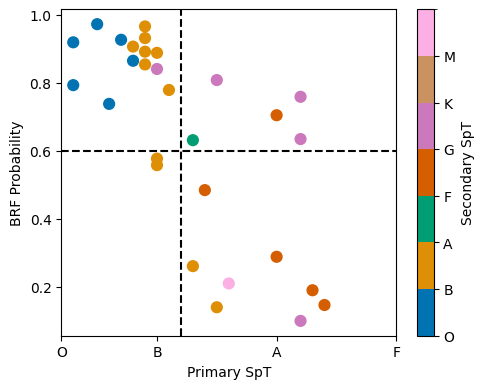

In [11]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from matplotlib.colors import ListedColormap

fig, ax = plt.subplots(figsize=(5, 4))

# Valores únicos y etiquetas espectrales
spectral_vals   = [0.2, 1, 2, 3, 4, 5, 6]
spectral_labels = ['O', 'B', 'A', 'F', 'G', 'K', 'M']

# --- paleta con “steps” colorblind ----------------------------------------
# 1) Obtener 7 colores seguros para daltónicos y convertir a cmap
colorblind_colors = sns.color_palette("colorblind", 7)
cmap = ListedColormap(colorblind_colors)

# 2) Normalización en intervalos cerrados (BoundaryNorm)
bounds = spectral_vals + [spectral_vals[-1] + 1]  # agrega un límite final
norm   = mpl.colors.BoundaryNorm(bounds, cmap.N)
# --------------------------------------------------------------------------

# Scatter plot
sc = ax.scatter(data["label_1"],
                data["B2_cut_probability"],
                c=data["label_2"],
                cmap=cmap,
                norm=norm,
               s=60)

# Líneas de referencia
ax.axvline(x=1.2, color="black", linestyle="--")
ax.axhline(y=0.6, color="black", linestyle="--")


# Eje x con etiquetas espectrales
ax.set_xticks(spectral_vals)
ax.set_xticklabels(spectral_labels)

# Colorbar con los mismos pasos y etiquetas
cbar = fig.colorbar(sc, ax=ax, boundaries=bounds, ticks=spectral_vals)
cbar.set_ticklabels(spectral_labels)
cbar.set_label("Secondary SpT")

# Etiquetas y límites
ax.set_xlabel("Primary SpT")
ax.set_ylabel("BRF Probability")
plt.xlim(0.2, 3)
plt.tight_layout()
plt.savefig("BinariesProbability.pdf", dpi=300)
plt.show()





In [12]:
14/16
2/16

8/13

5/13

0.38461538461538464

In [13]:
data.loc[(data["label_1"]<1.2)&(data["B2_cut_probability"]<0.6)]

,index,source_id,ra,dec,ra_error,dec_error,Parallax,Parallax_error,Parallax_over_error,pmRA,...,bp_rp,B2,B2_cut_split,B2_cut_probability,label_1,label_2,sp1,sp2,std_sp_y,std_sp_2
92,161199,2207689919743551360,346.009251,63.396868,0.163522,0.159288,1.793077,0.199338,8.995163,-2.871170,...,0.529920,NaN,NaN,0.558333,1.0,1.0,B0.5IV/V,B0.5IV/V,NaN,NaN
97,493240,2224860133836098560,338.104472,67.150678,0.015505,0.015190,0.958609,0.015688,61.106490,-2.056893,...,0.668183,NaN,NaN,0.577500,1.0,1.1,B1.5II,B1V,0.141421,0.0


In [14]:
skiff_binaries.loc[skiff_binaries["GroupID_skiff"]==21556.0][["skiff_type","type_codification_mean"]]

KeyError: "['type_codification_mean'] not in index"

In [ ]:
skiff_binaries_Group.loc[skiff_binaries_Group["type_codification_mean"]>35]["GroupID_skiff"]

In [ ]:
data = data.loc[data["B2_cut_split"]=="test"]

In [15]:
import matplotlib.pyplot as plt

In [17]:
df.loc[((df["sp_Monsalves+2025"]=="B0-B3")|
       (df["sp_Monsalves+2025"]=="O-B0"))&
       (df["sp_simbad"].isna())&
       (df["skiff_type"].isna())&
         (df["informacion_sp"]!=1)  ]

KeyError: 'sp_Monsalves+2025'

In [20]:
df

,source_id,ra,dec,ra_error,dec_error,Parallax,Parallax_error,Parallax_over_error,pmRA,pmDEC,...,bp_rp,B2,B2_cut_split,B2_cut_probability,label_1,label_2,sp1,sp2,std_sp_y,std_sp_2
91,5309311444605943296,145.739213,-53.104572,0.011662,0.010573,1.489259,0.012908,115.375984,-10.132837,3.827191,...,0.393489,NaN,NaN,0.190833,3.5,2.3,F5/7,A3/5V,NaN,NaN
92,2207689919743551360,346.009251,63.396868,0.163522,0.159288,1.793077,0.199338,8.995163,-2.871170,0.231896,...,0.529920,NaN,NaN,0.558333,1.0,1.0,B0.5IV/V,B0.5IV/V,NaN,NaN
93,5350386931282820736,161.102537,-59.510019,0.010959,0.011522,0.415555,0.013303,31.236921,-6.390428,1.931157,...,0.253186,NaN,NaN,0.779167,1.1,1.2,B1V,B2V,NaN,NaN
94,5995603100599846400,238.850867,-41.925175,0.017534,0.012522,2.244898,0.020835,107.743904,-11.836824,-12.649661,...,0.478761,NaN,NaN,0.147500,3.3,2.4,F5,A3,0.282843,0.141421
95,5338423042200185472,163.402740,-59.454943,0.011993,0.013100,0.227357,0.014639,15.531159,-5.339002,2.558730,...,0.419493,NaN,NaN,0.906667,1.0,0.8,B0III,O8V,NaN,NaN
96,2061288365972432640,305.089136,38.699888,0.013330,0.016138,0.556314,0.017532,31.730906,-3.604180,-5.657378,...,0.606512,NaN,NaN,0.891667,0.9,1.0,O9.5V,O9.5V,0.000000,0.057735
97,2224860133836098560,338.104472,67.150678,0.015505,0.015190,0.958609,0.015688,61.106490,-2.056893,-2.424933,...,0.668183,NaN,NaN,0.577500,1.0,1.1,B1.5II,B1V,0.141421,0.000000
98,4534148428383399424,283.359326,24.277980,0.011975,0.017860,1.581319,0.022069,71.654850,-1.349684,-3.995092,...,0.037450,NaN,NaN,0.140833,1.5,1.5,B5,B5,NaN,NaN
99,3436827611878196608,94.092472,28.851916,0.030575,0.027502,2.960554,0.033674,87.918520,-3.645100,-14.282759,...,0.418217,NaN,NaN,0.289167,2.0,3.5,A0V,F5III,NaN,NaN
100,2006644837072636160,337.475178,55.407944,0.011329,0.011124,0.264924,0.013736,19.286180,-3.592747,-3.093014,...,0.362787,NaN,NaN,0.965833,0.9,1.0,O9.2V,B,NaN,NaN


In [19]:
muestra = df.loc[(df["mon"].isna())&(df["B2_cut_probability"]>0.6)]

KeyError: 'mon'

In [18]:
muestra.loc[(muestra["informacion_sp"]!=1)&
       (muestra["B2_cut_probability"]>0.6)& 
        (muestra["sp_simbad"].isna())&
        (muestra["skiff_type"].isna())]

NameError: name 'muestra' is not defined

In [441]:
9089- 5158

3931

In [420]:
muestra.loc[(muestra["informacion_sp"]!=1)&
       (muestra["B2_cut_probability"]>0.6) 
        &((muestra["skiff_type"]=="OB")|(df["skiff_type"]=="em")|
          (muestra["skiff_type"]=="OB-") |(muestra["skiff_type"]=="OB+")|(muestra["skiff_type"]=="OBe")
          |(muestra["skiff_type"].isna()))
           &((muestra["sp_simbad"]=="OB")|(muestra["sp_simbad"]=="OBe")|(muestra["sp_simbad"].isna())),"nuevas"]=1

/tmp/ipykernel_260206/12481205.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  muestra.loc[(muestra["informacion_sp"]!=1)&


In [438]:
import numpy as np

In [439]:
muestra.loc[muestra["skiff_type"].str[0:2] == "OB","skiff_type"] = np.nan
muestra.loc[muestra["skiff_type"].str[0:2] == "em","skiff_type"] = np.nan
muestra.loc[muestra["sp_simbad"].str[0:2] == "OB","sp_simbad"] = np.nan

In [440]:
muestra.loc[(muestra["informacion_sp"]!=1)&
       (muestra["B2_cut_probability"]>0.6)& 
        (muestra["sp_simbad"].isna())&
        (muestra["skiff_type"].isna())]

,index,source_id,ra_1,dec_1,skiff_type,Bibcode_skiff,B2_cut_probability,B2_cut_split,Sp_monsalves2024,sp_Li2021,...,sp_Chini2012,sep_chini2012,sp_IACOB,sep_IACOB,sp_simbad,other_types_simbad,sep_simbad,sp_Monsalves+2025,informacion_sp,nuevas
184,996485,3102476670014708992,104.241042,-4.157301,NaN,['1965LS....C06....0N'],0.756667,NaN,B0-B3,NaN,...,NaN,NaN,NaN,NaN,NaN,*|NIR,0.027191,B0-B3,NaN,NaN
261,637291,5969709082049785088,254.474349,-40.223666,NaN,['1971PW&SO...1a...1S'],0.870000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,*|NIR,0.026445,NaN,NaN,NaN
1496,37180,458398565273206784,36.057134,57.090266,NaN,['1965LS....C05....0H'],0.839167,NaN,B0-B3,NaN,...,NaN,NaN,NaN,NaN,NaN,*|NIR,0.021379,B0-B3,NaN,NaN
1512,38388,4152555595038842752,275.724332,-13.168884,NaN,['1963LS....C04....0N'],0.744167,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,*|MIR|NIR,0.112990,NaN,NaN,NaN
1628,236078,3429176282258069888,87.927213,26.065150,NaN,['1965LS....C05....0H'],0.848333,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,*|NIR,0.027435,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98296,408295,1872532039423615488,314.120449,38.279262,NaN,['1960LS....C02....0S'],0.745714,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,*|NIR,0.090590,NaN,NaN,NaN
98309,725,457640417645156608,36.334965,56.853845,NaN,['1959LS....C01....0H'],0.952500,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,*|NIR,0.021629,NaN,NaN,NaN
98317,867,458342112224888064,34.586223,56.887143,NaN,['1965LS....C05....0H'],0.678333,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,*|NIR,0.020747,NaN,NaN,NaN
98323,610,459855418175704192,45.367249,56.751437,NaN,['1959LS....C01....0H'],0.905833,NaN,B4-B7,NaN,...,NaN,NaN,NaN,NaN,NaN,*|NIR,0.022710,B4-B7,NaN,NaN


In [414]:
df.loc[(df["informacion_sp"]!=1)&
       (df["B2_cut_probability"]>0.6) 
        &((df["skiff_type"]=="OB")|(df["skiff_type"]=="em")|
          (df["skiff_type"]=="OB-") |(df["skiff_type"]=="OB+")|(df["skiff_type"]=="OBe")
          |(df["skiff_type"].isna()))
           &((df["sp_simbad"]=="OB")|(df["sp_simbad"]=="OBe")|(df["sp_simbad"].isna())),"nuevas"] = 1

In [417]:
df.loc[(df["nuevas"]!=1)&(df["B2_cut_probability"]>0.6)&(df["B2_cut_probability"].isna()) ]

,index,source_id,ra_1,dec_1,skiff_type,Bibcode_skiff,B2_cut_probability,B2_cut_split,Sp_monsalves2024,sp_Li2021,...,sp_Chini2012,sep_chini2012,sp_IACOB,sep_IACOB,sp_simbad,other_types_simbad,sep_simbad,sp_Monsalves+2025,informacion_sp,nuevas


In [407]:
df.loc[(df["B2_cut_split"].isna())|
       (df["informacion_sp"]==1)&
      (df["sp_simbad"].isna())]

,index,source_id,ra_1,dec_1,skiff_type,Bibcode_skiff,B2_cut_probability,B2_cut_split,Sp_monsalves2024,sp_Li2021,...,sep_GOSS,sp_Chini2012,sep_chini2012,sp_IACOB,sep_IACOB,sp_simbad,other_types_simbad,sep_simbad,sp_Monsalves+2025,informacion_sp
126,3543,5944076481085129984,247.329813,-44.470641,O9.5Ia:,['1961MNRAS.122..239F'],0.854167,NaN,NaN,NaN,...,0.110948,NaN,NaN,NaN,NaN,NaN,*,0.110948,NaN,1.0
234,991716,5926219965542680832,259.680712,-50.534877,OB,['1995PASP..107..846D'],0.632500,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
6988,221037,5524705188351695744,133.858050,-41.078825,OB,['1966VeHei..18....9K'],0.630000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
8131,27098,5862055898575387904,196.943552,-64.202619,OB,['1966VeHei..18....9K'],0.925833,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
12828,1058666,4255232457604395648,282.608503,-4.248246,O9IIIne,['2021ApJS..253...54L'],0.880000,NaN,NaN,O9 IIIne,...,NaN,NaN,NaN,NaN,NaN,NaN,*|NIR,0.038802,NaN,1.0
14337,1064554,2013834509256723456,349.304250,60.107965,O9Vn,['2021ApJS..253...54L'],0.870759,NaN,NaN,O9 Vn,...,NaN,NaN,NaN,NaN,NaN,NaN,*,0.060371,NaN,1.0
15583,1058165,272086246921083136,67.653271,52.581842,O9.7III(n),['2021ApJS..253...54L'],0.760000,NaN,O-B0,O9.7 III(n),...,NaN,NaN,NaN,NaN,NaN,NaN,*|EB*|IR|NIR,0.011826,O-B0,1.0
15919,1076488,4214817880514992128,292.815765,-2.110223,B8V,['1964PDDO....2..417F'],0.747500,NaN,NaN,NaN,...,NaN,NaN,NaN,B8II,0.047455,NaN,*|**|EB*|SB*|V*,0.045275,NaN,1.0
21035,644235,5600421235540790016,118.948936,-28.701087,OB:,['1992AJ....104..590O'],0.732500,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,*|NIR|Pu*,0.058259,NaN,1.0
47462,688214,4156423268932861056,278.905053,-8.665912,B2Ib(n),['1993ApJS...89..293V'],0.909167,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,*|MIR|NIR,0.019364,NaN,1.0


In [405]:
df_candidates = df.loc[(df["informacion_sp"]==1)&
       (df["B2_cut_probability"]>0.6) 
        &((df["skiff_type"]!="OB")&(df["skiff_type"]!="em")|
          (df["skiff_type"]!="OB-") &(df["skiff_type"]!="OB+")&(df["skiff_type"]!="OBe")
          |(df["skiff_type"].isna()))
           &((df["sp_simbad"]=="OB")|(df["sp_simbad"]=="OBe")|(df["sp_simbad"].isna()))]

,index,source_id,ra_1,dec_1,skiff_type,Bibcode_skiff,B2_cut_probability,B2_cut_split,Sp_monsalves2024,sp_Li2021,...,sep_GOSS,sp_Chini2012,sep_chini2012,sp_IACOB,sep_IACOB,sp_simbad,other_types_simbad,sep_simbad,sp_Monsalves+2025,informacion_sp
2694,42234,5338324773341962496,164.355523,-60.111692,OB,['1965MmMtS..18.....G'],0.721667,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,OB,*|**,0.110876,NaN,NaN
3013,448684,6055101557424370944,190.985147,-63.081225,OB+,['1977AJ.....82..345M'],0.851667,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,*|MIR|NIR|WR*,0.094875,NaN,NaN
3438,640153,4093872636574597760,272.503987,-21.194547,OB,['1971PW&SO...1a...1S'],0.680833,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,OB,*|NIR,0.021918,NaN,NaN
3756,836782,5359027099794047488,154.133510,-50.008167,OB,['1971PW&SO...1a...1S'],0.639167,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,OB,*|NIR,0.132645,NaN,NaN
3889,629899,5863065769955067648,193.111570,-62.703068,OB,['1977AJ.....82..345M'],0.773333,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,*|MIR|NIR,0.078904,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98166,205709,5862733545640323584,193.294592,-63.646445,OB,['1977AJ.....82..345M'],0.840000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,*|NIR,0.118021,NaN,NaN
98219,209029,5355428222130041472,155.676755,-55.066406,NaN,[nan],0.844167,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
98263,1506,4053988195887916544,267.041398,-32.883848,OB,['1971PW&SO...1a...1S'],0.922500,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,OB,*|NIR,0.018861,NaN,NaN
98265,1101,4152488219896302976,276.424269,-13.456377,OB,['1955BOTT....2m..12I'],0.747500,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,OB,*|NIR,0.010588,NaN,NaN


In [402]:
df.loc[(df["Sp_monsalves2024"].notna())&(df["informacion_sp"]==1)][["sp_IACOB","sp_Monsalves+2025", "sp_GOSS", "sp_Chini2012", "sp_Li2021", "sp_ALS"]]

,sp_IACOB,sp_Monsalves+2025,sp_GOSS,sp_Chini2012,sp_Li2021,sp_ALS
53,NaN,O-B0,O5.5,NaN,O5.5 V(n)((fc)),NaN
6691,NaN,O-B0,NaN,NaN,O9.7,B0III
6852,NaN,B0-B3,NaN,NaN,NaN,B8II
15583,NaN,O-B0,NaN,NaN,O9.7 III(n),NaN
17066,NaN,O-B0,NaN,NaN,O9 V + B,NaN
17546,NaN,O-B0,NaN,NaN,O4 V((f)),NaN
33400,B1II,B0-B3,NaN,NaN,NaN,"B1II, B1 ..."
35827,NaN,B0-B3,NaN,NaN,NaN,B0Ibe2
35995,NaN,B0-B3,NaN,NaN,NaN,B0.5IV
44959,NaN,B8-A1,NaN,NaN,NaN,A0II


In [392]:
df.loc[(df["Sp_monsalves2024"]=="B0-B3")|(df["Sp_monsalves2024"]=="O-B0")]

,index,source_id,ra_1,dec_1,skiff_type,Bibcode_skiff,B2_cut_probability,B2_cut_split,Sp_monsalves2024,sp_Li2021,...,sep_GOSS,sp_Chini2012,sep_chini2012,sp_IACOB,sep_IACOB,sp_simbad,other_types_simbad,sep_simbad,sp_Monsalves+2025,informacion_sp
53,802394,2003815312630659584,343.937240,56.476826,O5.5V((fc))(n),['2021ApJS..253...54L'],0.914119,NaN,O-B0,O5.5 V(n)((fc)),...,0.136293,NaN,NaN,NaN,NaN,O5.5V(n)((fc))+B,*|Em*|NIR|Opt|SB*|V*?,0.069623,O-B0,1.0
184,996485,3102476670014708992,104.241042,-4.157301,OB-,['1965LS....C06....0N'],0.756667,NaN,B0-B3,NaN,...,NaN,NaN,NaN,NaN,NaN,OB-,*|NIR,0.027191,B0-B3,NaN
1496,37180,458398565273206784,36.057134,57.090266,OB-,['1965LS....C05....0H'],0.839167,NaN,B0-B3,NaN,...,NaN,NaN,NaN,NaN,NaN,OB-,*|NIR,0.021379,B0-B3,NaN
3234,1000737,3344727089097100288,94.645321,14.647768,em,['1997AAHam..11....1K'],0.705833,NaN,B0-B3,NaN,...,NaN,NaN,NaN,NaN,NaN,B,*|Em*|NIR|Opt,0.006119,B0-B3,NaN
3245,38832,460612736870450944,43.138281,57.032408,OB-,['1959LS....C01....0H'],0.660000,NaN,B0-B3,NaN,...,NaN,NaN,NaN,NaN,NaN,OB-,*|NIR,0.021525,B0-B3,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96752,928368,2007038805850171136,341.604998,57.110400,OB,['1964LS....C03....0H'],0.751667,NaN,B0-B3,NaN,...,NaN,NaN,NaN,NaN,NaN,B,*|NIR,0.070733,B0-B3,NaN
96995,579853,3436639079993718784,91.982364,28.782785,OB-,['1965LS....C05....0H'],0.804167,NaN,B0-B3,NaN,...,NaN,NaN,NaN,NaN,NaN,OB-,*|NIR,0.016379,B0-B3,NaN
97791,953316,2025106079688221696,294.547800,27.186849,OB+,['1960LS....C02....0S'],0.860000,NaN,B0-B3,NaN,...,NaN,NaN,NaN,NaN,NaN,B0Ib,*|NIR|Opt|s*b,0.120089,B0-B3,NaN
98573,1088641,3377474634180963584,95.135689,23.317308,O6Vnz + O9Vn,['2021ApJS..253...54L'],0.795000,NaN,O-B0,O6 Vzn + O9 Vn,...,NaN,NaN,NaN,B2,0.041553,B2,*|**|EB*|NIR|V*,0.041892,O-B0,1.0


In [396]:
df_candidates.loc[(df_candidates["Sp_monsalves2024"]=="B0-B3")|(df_candidates["Sp_monsalves2024"]=="O-B0")].sample(20)

,index,source_id,ra_1,dec_1,skiff_type,Bibcode_skiff,B2_cut_probability,B2_cut_split,Sp_monsalves2024,sp_Li2021,...,sep_GOSS,sp_Chini2012,sep_chini2012,sp_IACOB,sep_IACOB,sp_simbad,other_types_simbad,sep_simbad,sp_Monsalves+2025,informacion_sp
44163,771900,3428728501852004224,84.993619,24.605918,NaN,[nan],0.610833,NaN,B0-B3,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,*|NIR,0.007369,B0-B3,NaN
48352,844604,2061043965141698944,304.916513,37.896838,NaN,[nan],0.605833,NaN,B0-B3,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,*|NIR,0.067135,B0-B3,NaN
85284,734943,3373210006532702080,92.963587,17.262960,NaN,[nan],0.817500,NaN,B0-B3,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,*|NIR,0.008388,B0-B3,NaN
46435,814100,180790154334589696,80.080003,32.138043,NaN,[nan],0.631667,NaN,B0-B3,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,*|Em*|NIR|Opt,0.042819,B0-B3,NaN
38417,951397,247199114766785536,61.920476,49.067586,OB,['1955BOTT....2m...5G'],0.841667,NaN,B0-B3,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,*|NIR,0.010795,B0-B3,NaN
39081,958948,458436120468296960,36.042375,57.325360,NaN,[nan],0.776667,NaN,B0-B3,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,*|IR|NIR,0.018341,B0-B3,NaN
84248,717084,3354111489560861568,102.986443,13.859915,NaN,[nan],0.824167,NaN,B0-B3,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,*|NIR,0.003212,B0-B3,NaN
80692,666841,3126300067629164544,102.937970,2.474728,NaN,[nan],0.646548,NaN,B0-B3,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,*|NIR,0.012484,B0-B3,NaN
68435,868189,2069008793008339584,307.125065,43.092394,NaN,[nan],0.792500,NaN,B0-B3,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,*|MIR|NIR|SB*,0.082490,B0-B3,NaN
39885,970945,425338827603276416,9.922322,58.743765,NaN,[nan],0.659167,NaN,B0-B3,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,*|EB*|NIR,0.044816,B0-B3,NaN


In [386]:
df_candidates.groupby("skiff_type").count().sort_values(by="source_id",ascending=False).head(10)

,index,source_id,ra_1,dec_1,Bibcode_skiff,B2_cut_probability,B2_cut_split,Sp_monsalves2024,sp_Li2021,Cat,...,sep_GOSS,sp_Chini2012,sep_chini2012,sp_IACOB,sep_IACOB,sp_simbad,other_types_simbad,sep_simbad,sp_Monsalves+2025,informacion_sp
skiff_type,,,,,,,,,,,,,,,,,,,,,
OB,401,401,401,401,401,401,0,8,0,265,...,0,0,0,0,0,284,394,394,9,0
em,118,118,118,118,118,118,0,6,0,9,...,0,0,0,0,0,5,115,115,6,0
OB-,82,82,82,82,82,82,0,1,0,42,...,0,0,0,0,0,15,77,77,1,0
OB+,21,21,21,21,21,21,0,0,0,19,...,0,0,0,0,0,6,20,20,0,0
OBe,19,19,19,19,19,19,0,1,0,11,...,0,0,0,0,0,15,19,19,1,0


In [112]:
path_plots = "/home/nicolas/nico/Data/Masivas/Data_OB_stars/resultados_V2/plots/"

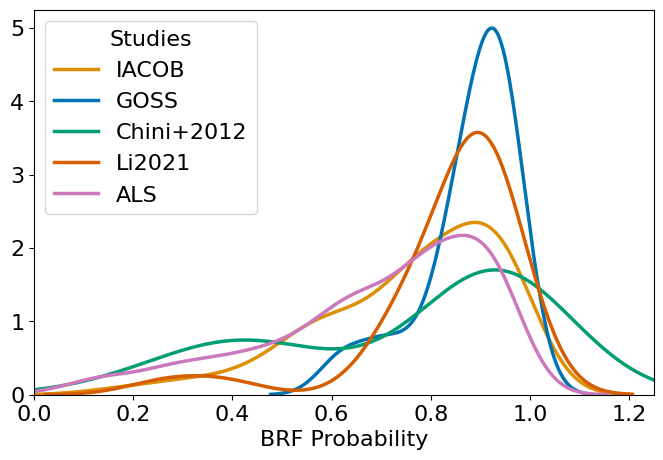

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_kde_comparativo(df_with_sp_literature):
    """
    Esta función genera un solo gráfico con líneas KDE de distintos colores
    basadas en las diferentes condiciones aplicadas a las columnas del DataFrame.
    Utiliza una paleta de colores amigable para personas con daltonismo.
    
    :param df: DataFrame que contiene los datos a analizar
    """
    # Filtrar los datos para las diferentes condiciones
    data_IACOB = df_with_sp_literature.loc[(df_with_sp_literature["sp_IACOB"].notna())]["B2_cut_probability"]
    data_GOSS = df_with_sp_literature.loc[(df_with_sp_literature["sp_GOSS"].notna())]["B2_cut_probability"]
    data_Chini = df_with_sp_literature.loc[(df_with_sp_literature["sp_Chini2012"].notna())]["B2_cut_probability"]
    data_li = df_with_sp_literature.loc[(df_with_sp_literature['sp_Li2021'].notna())]["B2_cut_probability"]
    data_ALS = df_with_sp_literature.loc[(df_with_sp_literature['sp_ALS'].notna())&
                                        (df_with_sp_literature["Cat"]=="M")]["B2_cut_probability"]

    # Crear la figura
    plt.figure(figsize=(8, 5))
    
    # Establecer la paleta de colores amigable para daltónicos
    colores = sns.color_palette("colorblind", n_colors=5)
    
    # Dibujar KDE para cada conjunto de datos con la paleta de colores seleccionada
    sns.kdeplot(data_IACOB, label='IACOB', color=colores[1], linewidth=2.5)
    sns.kdeplot(data_GOSS, label='GOSS', color=colores[0], linewidth=2.5)
    sns.kdeplot(data_Chini, label='Chini+2012', color=colores[2], linewidth=2.5)
    sns.kdeplot(data_li, label='Li2021', color=colores[3], linewidth=2.5)
    sns.kdeplot(data_ALS, label='ALS', color=colores[4], linewidth=2.5)
    plt.tick_params(axis='x', labelsize=16)  # Aumentar el tamaño de los ticks del eje x
    plt.tick_params(axis='y', labelsize=16) 
    # Añadir leyenda y etiquetas
    plt.legend()
    plt.xlabel('BRF Probability', fontsize=16)
    plt.ylabel("")
    plt.xlim(0,1.25)
    plt.legend(title='Studies', fontsize=16, title_fontsize=16)
    # Mostrar gráfico
    plt.savefig(f"{path_plots}/Comparation_massive_star_studies.pdf", format='pdf', bbox_inches='tight')
    plt.show()

# Llamar a la función con tu DataFrame
plot_kde_comparativo(df)


In [52]:
# Filtrar los datos para las diferentes condiciones
data_IACOB = df_with_sp_literature.loc[(df_with_sp_literature["sp_IACOB"].notna())]
data_GOSS = df_with_sp_literature.loc[(df_with_sp_literature["sp_GOSS"].notna())]
data_Chini = df_with_sp_literature.loc[(df_with_sp_literature["sp_Chini2012"].notna())]
data_li = df_with_sp_literature.loc[(df_with_sp_literature['sp_Li2021'].notna())]
data_ALS = df_with_sp_literature.loc[(df_with_sp_literature['sp_ALS'].notna())&
                                    (df_with_sp_literature["Cat"]=="M")]


In [71]:
len(data_IACOB), len(data_GOSS),len(data_Chini),len(data_li),len(data_ALS)

(124, 36, 17, 29, 831)

In [53]:
len(data_IACOB.loc[data_IACOB["B2_cut_probability"]<0.5]) / len(data_IACOB)

0.10483870967741936

In [58]:
data_IACOB.loc[data_IACOB["B2_cut_probability"]<0.5]["sp_IACOB"]

7602            B3II
18158            B2V
21684          B3III
31431             B9
31775             B9
32734          B2.5V
56591          B1Vne
98486           B2IV
98779           B8Ib
99045    WN5b(h)+B3I
99082          B3III
99123            B2V
99155            B2V
Name: sp_IACOB, dtype: object

In [54]:
len(data_GOSS.loc[data_GOSS["B2_cut_probability"]<0.5]) / len(data_GOSS)

0.0

In [59]:
len(data_li.loc[data_li["B2_cut_probability"]<0.5]) / len(data_li)

0.06896551724137931

In [60]:
data_li.loc[data_li["B2_cut_probability"]<0.5]

,index,source_id,ra_1,dec_1,skiff_type,Bibcode_skiff,B2_cut_probability,B2_cut_split,sp_Li2021,Cat,...,sep_GOSS,sp_Chini2012,sep_chini2012,sp_IACOB,sep_IACOB,sp_simbad,other_types_simbad,sep_simbad,sp_Monsalves+2024,informacion_sp
15651,1060594,272284953588327296,65.353392,52.950090,O9.7IV(n),['2021ApJS..253...54L'],0.385000,NaN,O9.7 IV(n),NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,*|EB*|NIR,0.026420,NaN,1.0
95820,841690,246809440972012544,59.715112,48.301496,O9.7n,['2021ApJS..253...54L'],0.264167,NaN,O9.7 n,M,...,NaN,NaN,NaN,NaN,NaN,O9.7IVn,*|NIR,0.032896,NaN,1.0


In [55]:
len(data_Chini.loc[data_Chini["B2_cut_probability"]<0.5]) / len(data_Chini)

0.29411764705882354

In [73]:
data_Chini.loc[data_Chini["B2_cut_probability"]<0.5]

,index,source_id,ra_1,dec_1,skiff_type,Bibcode_skiff,B2_cut_probability,B2_cut_split,sp_Li2021,Cat,...,sep_GOSS,sp_Chini2012,sep_chini2012,sp_IACOB,sep_IACOB,sp_simbad,other_types_simbad,sep_simbad,sp_Monsalves+2024,informacion_sp
12031,1066806,5895402235155675392,214.787610,-55.882293,OB-,['1964MeLu2.141....1L'],0.359167,NaN,NaN,NaN,...,NaN,B4IV/V,0.198562,NaN,NaN,B4IV/V,*|Er*|Ir*|NIR|UV|V*,0.198944,NaN,1.0
26867,1084217,5332528491634285440,177.953874,-64.595679,B4V,['1975MSS...C01....0H'],0.225000,NaN,NaN,NaN,...,NaN,B4V,0.265642,NaN,NaN,NaN,*|**|NIR|Pu*,0.219896,NaN,1.0
87388,1044421,5843519957910366848,195.772072,-71.475750,em,['1890AN....126..117F'],0.431667,NaN,NaN,NaN,...,NaN,B1.5IIIne,0.192488,NaN,NaN,NaN,*|**,0.183679,NaN,1.0
96669,976608,5255904179120926336,150.891987,-61.884022,B8e,['1977PW&SO...2...71S'],0.419167,NaN,NaN,NaN,...,NaN,B4:Vne,0.292110,NaN,NaN,B3/5Vne,*|**|Be*|Em*|IR|MIR|NIR|UV|V*,0.292172,NaN,1.0
98475,382684,2019155046038630144,290.488594,22.506397,B4V,['1985ApJS...59...95A'],0.460833,NaN,NaN,NaN,...,NaN,B2.5V,0.099113,NaN,NaN,NaN,*|**,0.095680,NaN,1.0


In [56]:
data_Chini.loc[data_Chini["B2_cut_probability"]<0.5]

,index,source_id,ra_1,dec_1,skiff_type,Bibcode_skiff,B2_cut_probability,B2_cut_split,sp_Li2021,Cat,...,sep_GOSS,sp_Chini2012,sep_chini2012,sp_IACOB,sep_IACOB,sp_simbad,other_types_simbad,sep_simbad,sp_Monsalves+2024,informacion_sp
12031,1066806,5895402235155675392,214.787610,-55.882293,OB-,['1964MeLu2.141....1L'],0.359167,NaN,NaN,NaN,...,NaN,B4IV/V,0.198562,NaN,NaN,B4IV/V,*|Er*|Ir*|NIR|UV|V*,0.198944,NaN,1.0
26867,1084217,5332528491634285440,177.953874,-64.595679,B4V,['1975MSS...C01....0H'],0.225000,NaN,NaN,NaN,...,NaN,B4V,0.265642,NaN,NaN,NaN,*|**|NIR|Pu*,0.219896,NaN,1.0
87388,1044421,5843519957910366848,195.772072,-71.475750,em,['1890AN....126..117F'],0.431667,NaN,NaN,NaN,...,NaN,B1.5IIIne,0.192488,NaN,NaN,NaN,*|**,0.183679,NaN,1.0
96669,976608,5255904179120926336,150.891987,-61.884022,B8e,['1977PW&SO...2...71S'],0.419167,NaN,NaN,NaN,...,NaN,B4:Vne,0.292110,NaN,NaN,B3/5Vne,*|**|Be*|Em*|IR|MIR|NIR|UV|V*,0.292172,NaN,1.0
98475,382684,2019155046038630144,290.488594,22.506397,B4V,['1985ApJS...59...95A'],0.460833,NaN,NaN,NaN,...,NaN,B2.5V,0.099113,NaN,NaN,NaN,*|**,0.095680,NaN,1.0


In [61]:
len(data_ALS.loc[data_ALS["B2_cut_probability"]<0.5]) / len(data_ALS)

0.18892900120336945

In [80]:
df.loc[(df["informacion_sp"]!=1)&(df["B2_cut_probability"]>0.6)]

,index,source_id,ra_1,dec_1,skiff_type,Bibcode_skiff,B2_cut_probability,B2_cut_split,sp_Li2021,Cat,...,sep_GOSS,sp_Chini2012,sep_chini2012,sp_IACOB,sep_IACOB,sp_simbad,other_types_simbad,sep_simbad,sp_Monsalves+2024,informacion_sp
12179,128947,5335974739013107968,172.564840,-60.540902,NaN,[nan],0.694167,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,*|NIR,0.086293,NaN,NaN
12185,129018,5876406385119258880,226.396636,-60.538898,NaN,[nan],0.673333,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,*|NIR,0.068632,NaN,NaN
12187,129073,5338085629570315520,165.829815,-60.537014,NaN,[nan],0.636667,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,*|NIR,0.108977,NaN,NaN
12193,129173,5254793981629134464,155.790075,-60.533322,NaN,[nan],0.711667,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,*|NIR,0.098973,NaN,NaN
12198,129357,5338207327417387520,163.136670,-60.526753,NaN,[nan],0.835833,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,*|NIR|V*|cC*,0.124632,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97010,576307,4153681052610553088,274.452080,-11.933879,NaN,[nan],0.867500,NaN,NaN,M,...,NaN,NaN,NaN,NaN,NaN,NaN,*|NIR,0.034641,NaN,NaN
97012,576311,4153684518596822528,274.649514,-11.929172,NaN,[nan],0.839167,NaN,NaN,M,...,NaN,NaN,NaN,NaN,NaN,NaN,*|NIR,0.030933,NaN,NaN
97021,576446,4153686958138242560,274.462607,-11.909250,NaN,[nan],0.890833,NaN,NaN,M,...,NaN,NaN,NaN,NaN,NaN,NaN,*|NIR,0.033676,NaN,NaN
97027,373454,4053273616438013440,264.410959,-35.036245,NaN,[nan],0.703333,NaN,NaN,M,...,NaN,NaN,NaN,NaN,NaN,NaN,*|NIR,0.012061,NaN,NaN


In [39]:
path_catalog = '/home/nicolas/nico/Data/Masivas/Data_OB_stars/comparation_skiff_simbad/'
simbad = pd.read_csv(f"{path_catalog}OBAGDR3_2arcsecSimbad/Revised/OBAGDR3_2arcsecSimbad_codified.csv", index_col="Unnamed: 0")
skiff = pd.read_csv(f"{path_catalog}/OBAGDR3_2arcsecSkiff/Revised/sd_3/OBAGDR3_2arcsecSkiff_grouped_sd_3_without_OB_without_non_consec_lum.csv")

/tmp/ipykernel_9379/1468164633.py:3: DtypeWarning: Columns (1,2,9) have mixed types. Specify dtype option on import or set low_memory=False.
  skiff = pd.read_csv(f"{path_catalog}/OBAGDR3_2arcsecSkiff/Revised/sd_3/OBAGDR3_2arcsecSkiff_grouped_sd_3_without_OB_without_non_consec_lum.csv")


In [40]:
df_coded_nico = pd.read_csv("/home/nicolas/nico/Data/Masivas/Data_OB_stars/skiff_2arcsec_OBAGDR3_prep_V2.csv")

In [41]:
df_coded_nico = df_coded_nico[['index', 'source_id', 'ra', 'dec', 'ra_error', 'dec_error', 'parallax',
       'parallax_error', 'parallax_over_error', 'pmra', 'pmdec', 'pmra_error',
       'pmdec_error', 'phot_g_mean_mag', 'phot_bp_mean_mag', 'phot_g_n_obs',
       'phot_g_mean_flux_over_error', 'phot_rp_n_obs',
       'phot_rp_mean_flux_over_error', 'phot_bp_n_obs',
       'phot_bp_mean_flux_over_error', 'phot_rp_mean_mag', 'ph_qual',
       'tmass_oid', 'j_m', 'h_m', 'ks_m', 'j_ks_0', 'J-H',
       'astrometric_sigma5d_max', 'astrometric_excess_noise',
       'visibility_periods_used', 'ruwe', 'astrometric_gof_al',
       'ipd_gof_harmonic_amplitude', 'ipd_frac_odd_win', 'ipd_frac_multi_peak',
       'matched_transits_removed', 'astrometric_params_solved',
       'astrometric_excess_noise_sig', 'phot_variable_flag', 'skiff_type',
       'Bibcode', 'ra_skiff', 'dec_skiff', 'GroupID_skiff', 'GroupSize_skiff',
       'Sep_skiff', 'mk','std_sp','label']]

In [42]:
df_coded_nico_with_group = df_coded_nico.loc[df_coded_nico["GroupID_skiff"].notna()].reset_index(drop=True)
df_coded_nico_without_group = df_coded_nico.loc[df_coded_nico["GroupID_skiff"].isna()].reset_index(drop=True)


In [43]:
df_coded_nico_without_group["Bibcode_list"] = df_coded_nico_without_group["Bibcode"] 
df_coded_nico_without_group["source_id_list"] = df_coded_nico_without_group["source_id"] 
df_coded_nico_without_group["index_list"] = df_coded_nico_without_group["index"] 
df_coded_nico_without_group["skiff_type_list"] = df_coded_nico_without_group["skiff_type"] 


In [44]:
# Lista de columnas a transformar
cols_to_transform = [
    'Bibcode',
    'index',
    'skiff_type',
    'source_id']


for col in cols_to_transform:
    name = col + "_list"
    df_coded_nico_with_group[name] = (
        df_coded_nico_with_group
        .groupby('GroupID_skiff')[col]
        .transform(lambda x: ', '.join(x.dropna().astype(str).unique()))
    )


In [45]:
df_coded_nico_with_group[["mk", "std_sp", "label"]] = df_coded_nico_with_group.groupby("GroupID_skiff")[["mk", "std_sp", "label"]].transform(lambda x: x.fillna(method='ffill').fillna(method='bfill'))


/tmp/ipykernel_9379/2739493931.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_coded_nico_with_group[["mk", "std_sp", "label"]] = df_coded_nico_with_group.groupby("GroupID_skiff")[["mk", "std_sp", "label"]].transform(lambda x: x.fillna(method='ffill').fillna(method='bfill'))
/tmp/ipykernel_9379/2739493931.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_coded_nico_with_group[["mk", "std_sp", "label"]] = df_coded_nico_with_group.groupby("GroupID_skiff")[["mk", "std_sp", "label"]].transform(lambda x: x.fillna(method='ffill').fillna(method='bfill'))


In [46]:
df_coded_nico_concat = pd.concat([df_coded_nico_without_group,df_coded_nico_with_group])

In [47]:
import ast
skiff = pd.read_csv(f"{path_catalog}/OBAGDR3_2arcsecSkiff/Revised/sd_3/OBAGDR3_2arcsecSkiff_grouped_sd_3_without_OB_without_non_consec_lum.csv")
skiff = skiff[['source_id', 'lum_codification_mean']]
skiff['source_id'] = skiff['source_id'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) and x.startswith('[') else x)
skiff = skiff.explode("source_id").reset_index(drop=True)
skiff["source_id"] = skiff["source_id"].astype(int)

/tmp/ipykernel_9379/879922521.py:2: DtypeWarning: Columns (1,2,9) have mixed types. Specify dtype option on import or set low_memory=False.
  skiff = pd.read_csv(f"{path_catalog}/OBAGDR3_2arcsecSkiff/Revised/sd_3/OBAGDR3_2arcsecSkiff_grouped_sd_3_without_OB_without_non_consec_lum.csv")


In [48]:
df_coded_nico_concat = df_coded_nico_concat.merge(skiff,how="left",on="source_id")

In [49]:
df = df[['index',"source_id",
       'B2_cut_probability', 'B2_cut_split', 'sp_Li2021', 'Cat', 'sp_ALS',
       'Ra_ALS', 'DEC_ALS', 'Sep_Li2021', 'Sep_ALS', 'sp_GOSS', 'LC_goss',
       'sep_GOSS', 'sp_Chini2012', 'sep_chini2012', 'sp_IACOB', 'sep_IACOB',
       'sp_simbad', 'other_types_simbad', 'sep_simbad', 'sp_Monsalves+2025']].merge(df_coded_nico_concat,how="left",on=["source_id","index"])

In [50]:
df = df.drop_duplicates(subset="source_id")

In [51]:
df

,index,source_id,B2_cut_probability,B2_cut_split,sp_Li2021,Cat,sp_ALS,Ra_ALS,DEC_ALS,Sep_Li2021,...,GroupSize_skiff,Sep_skiff,mk,std_sp,label,Bibcode_list,source_id_list,index_list,skiff_type_list,lum_codification_mean
0,281628,458762022584923136,0.555833,train,NaN,M,A0Iab,33.994563,58.293614,NaN,...,12.0,0.038573,2.0,0.107497,2.1,"1959LS....C01....0H, 1963JO.....46..243B, 1968...",458762022584923136,"281628, 281630, 281632, 281633, 281635, 281637...","A0Iab, A2Iab, B9Iab, A0Ia, A1Ib, A2Ia, OB, A0:...",0.0
11,53573,458457320427789824,0.951111,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.064810,NaN,NaN,NaN,1949UppAn...3b....W,458457320427789824,53573,OB,NaN
12,366012,4069663589522760448,0.715833,train,NaN,M,"B1/2III, B1V ...",271.012200,-22.565961,NaN,...,7.0,0.066400,1.3,0.149109,1.3,"1937LicOB..18...89Z, 1943ApJ....97..300N, 1932...",4069663589522760448,"366012, 366014, 366017, 366027, 366029, 366031...","B3, B5, OB, B1/2III, B1V",3.0
17,1079351,4042411609752563200,0.953333,train,NaN,M,"B1Ib, B2IB/II ...",269.984779,-33.890832,NaN,...,6.0,0.039397,1.1,0.152753,1.2,"1971PW&SO...1a...1S, 1977ApJS...35..111G, 1982...",4042411609752563200,"1079350, 1079351, 1079352, 1079353, 1079354, 1...","OB:, B1Ib, B2Ib/II, B, OB",0.0
20,1047552,3397264469089651456,0.132500,train,NaN,NaN,NaN,NaN,NaN,NaN,...,9.0,0.210419,1.8,0.048795,1.8,"1959ApJ...130..159O, 1970PASP...82.1357W, 1969...",3397264469089651456,"1047552, 1047553, 1047554, 1047555, 1047556, 1...","B8V, em, B7IV, B8",3.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126265,1089111,4054578186917712512,0.819167,train,NaN,M,"B2II, B5V, B3II ...",263.275062,-33.057809,NaN,...,5.0,0.130188,1.2,0.152753,1.3,"1982MSS...C03....0H, 1973Obs....93...75W, 1971...",4054578186917712512,"1089111, 1089112, 1089113, 1089114, 1089115","B2II, B5Vn, OB, B3II, B",2.0
126269,871512,511264699246655488,0.815000,train,NaN,M,"B5Ib, B6Iab ...",26.599083,61.258254,NaN,...,13.0,0.014557,1.5,0.230940,1.3,"1974AJ.....79..597M, 1961AbaOB..26...35K, 1959...",511264699246655488,"871512, 871516, 871517, 871519, 871521, 871557...","B5Ib, B5I, OB, B6Iabe, B6Iab, B2, B5:, B1, B0",0.0
126278,965933,5971216963502652288,0.948333,train,NaN,M,"B1.5IV, B2III ...",253.134733,-38.436110,NaN,...,3.0,0.068867,1.2,0.070711,1.2,"1982MSS...C03....0H, 1977ApJS...35..111G, 1966...",5971216963502652288,"965933, 965935, 965937","B2III, B1.5IV, OB",2.5
126280,49625,5932571569353682560,0.644167,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.0,0.047647,NaN,NaN,NaN,"1962MNRAS.124..445T, 2017MNRAS.469.1330A",5932571569353682560,"49625, 49629","B8:III, B7III + B8?",2.0


In [52]:
df.to_csv('/home/nicolas/nico/Data/Masivas/Data_OB_stars/resultados_V2/Discussion/Masivas_untilG12_Summary.csv',index=False)

In [517]:
# falta sumar al label + 10 
# hacer el diagrama HR

,index,source_id,B2_cut_probability,B2_cut_split,sp_Li2021,Cat,sp_ALS,Ra_ALS,DEC_ALS,Sep_Li2021,...,Bibcode,ra_skiff,dec_skiff,GroupID_skiff,GroupSize_skiff,Sep_skiff,mk,std_sp,label,lum_codification_mean
0,281628,458762022584923136,0.555833,train,NaN,M,A0Iab,33.994563,58.293614,NaN,...,1959LS....C01....0H,02 15 58.70,+58 17 37.0,3857.0,12.0,0.038573,2.0,0.107497,2.1,0.0
12,366012,4069663589522760448,0.715833,train,NaN,M,"B1/2III, B1V ...",271.012200,-22.565961,NaN,...,1937LicOB..18...89Z,18 04 02.93,-22 33 57.4,4947.0,7.0,0.066400,1.3,0.149109,1.3,3.0
17,1079351,4042411609752563200,0.953333,train,NaN,M,"B1Ib, B2IB/II ...",269.984779,-33.890832,NaN,...,1977ApJS...35..111G,17 59 56.35,-33 53 27.0,23485.0,6.0,0.039397,1.1,0.152753,1.2,0.0
20,1047552,3397264469089651456,0.132500,train,NaN,NaN,NaN,NaN,NaN,NaN,...,1959ApJ...130..159O,05 32 14.57,+17 03 21.8,16807.0,9.0,0.210419,1.8,0.048795,1.8,3.5
29,13397,5932569095538165632,0.732500,test,NaN,NaN,NaN,NaN,NaN,NaN,...,1962MNRAS.124..445T,16 13 12.85,-54 17 24.0,487.0,2.0,0.063130,1.8,NaN,1.8,2.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126265,1089111,4054578186917712512,0.819167,train,NaN,M,"B2II, B5V, B3II ...",263.275062,-33.057809,NaN,...,1982MSS...C03....0H,17 33 06.02,-33 03 28.0,25544.0,5.0,0.130188,1.2,0.152753,1.3,2.0
126269,871512,511264699246655488,0.815000,train,NaN,M,"B5Ib, B6Iab ...",26.599083,61.258254,NaN,...,1974AJ.....79..597M,01 46 23.78,+61 15 29.7,11703.0,13.0,0.014557,1.5,0.230940,1.3,0.0
126278,965933,5971216963502652288,0.948333,train,NaN,M,"B1.5IV, B2III ...",253.134733,-38.436110,NaN,...,1982MSS...C03....0H,16 52 32.33,-38 26 10.0,12961.0,3.0,0.068867,1.2,0.070711,1.2,2.5
126280,49625,5932571569353682560,0.644167,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1962MNRAS.124..445T,16 13 18.06,-54 10 04.1,1012.0,2.0,0.047647,NaN,NaN,NaN,2.0


In [54]:
df = df.loc[df["lum_codification_mean"].notna()]

In [76]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [84]:
df["Mabs_G"] = df["phot_g_mean_mag"] - 5* np.log10((1/(df["parallax"] *0.001))) + 5

/home/nicolas/miniconda3/envs/RF/lib/python3.11/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/tmp/ipykernel_9379/3856999071.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Mabs_G"] = df["phot_g_mean_mag"] - 5* np.log10((1/(df["parallax"] *0.001))) + 5


<Axes: xlabel='parallax_error', ylabel='Count'>

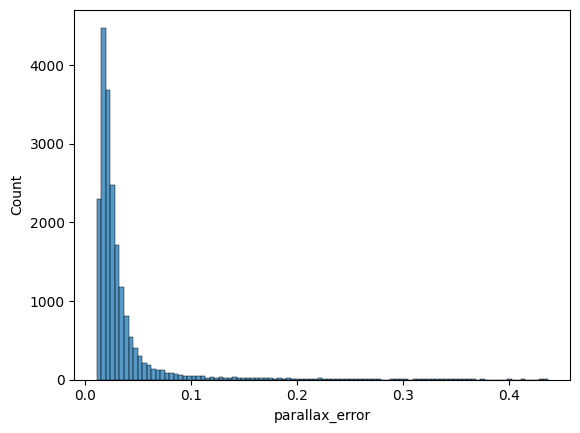

In [97]:
sns.histplot(data=df,x="parallax_error",bins=100)

In [104]:
test = df.loc[df["parallax_error"]<np.quantile(df["parallax_error"],0.25)]

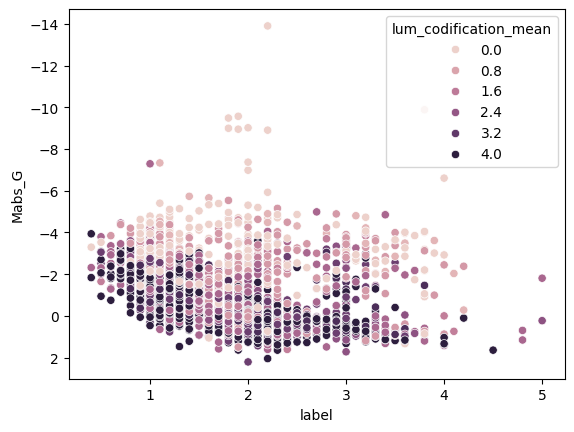

In [107]:
sns.scatterplot(data=test,x="label",y="Mabs_G",hue="lum_codification_mean")
plt.gca().invert_yaxis()